# Extract Patches

In order to extract patches from a video, first of all, let's create a dictionary called **frames**, which index are the number of the frame and every record contains a list of object that are in the scene. For an object we have:

- **tag**: unique identifier of the object on stage;
- **x**: position along the x axis;
- **y**: position along the y axis;
- **w**: width of the patch;
- **h**: height of the patch.

In [1]:
import json

frames = {}
frame_idices=[]
frame_order=[0]   # The frame id regarding to line
num_frames=0

with open("/home/pducanh/Desktop/pcgvs/data/meta.txt", 'r') as f:
    lines = f.readlines()
    for line in lines:
        frame_index = line.split()[22][0:5]  # the last number in datetime
        frame_idices.append(frame_index)
        
    for i in range(0,len(frame_idices)-1):
        if (frame_idices[i]!=frame_idices[i+1]):
            num_frames += 1
            frame_order.append(num_frames)
        else:
            frame_order.append(num_frames) 
            
    for i, num_frames in enumerate(frame_order):
        line = lines[i]
        object_id = line.split()[3][0:5]
        x =  line.split()[7][1:-1]
        y = line.split()[8][0:-1]
        w = line.split()[9][0:-1]
        h = line.split()[10][0:-2]
        
        if int(num_frames) not in frames.keys():
            frames[int(num_frames)] = []
        frames[int(num_frames)].append([object_id, int(x), int(y), int(w), int(h)])
        
with open("/home/pducanh/Desktop/pcgvs/data/meta.json", "w") as f:
    json.dump(frames, f, indent=4)

frames

{0: [['16936', 1585, 531, 1639, 704]],
 1: [['16947', 111, 880, 279, 1077],
  ['16948', 111, 880, 279, 1077],
  ['16949', 111, 880, 279, 1077]],
 2: [['16947', 119, 885, 269, 1078],
  ['16948', 119, 885, 269, 1078],
  ['16949', 119, 885, 269, 1078]],
 3: [['16948', 123, 886, 263, 1079], ['16949', 123, 886, 263, 1079]],
 4: [['16948', 1586, 528, 1639, 704], ['16949', 1586, 528, 1639, 704]],
 5: [['16948', 1586, 530, 1640, 702], ['16949', 1586, 530, 1640, 702]],
 6: [['16948', 1587, 530, 1639, 695], ['16949', 1587, 530, 1639, 695]],
 7: [['16948', 1587, 526, 1640, 691], ['16949', 1587, 526, 1640, 691]],
 8: [['16948', 1587, 525, 1639, 685], ['16949', 1587, 525, 1639, 685]],
 9: [['16948', 1588, 522, 1641, 684], ['16949', 1588, 522, 1641, 684]],
 10: [['16948', 1589, 524, 1641, 683], ['16949', 1589, 524, 1641, 683]],
 11: [['16948', 1589, 519, 1640, 683], ['16949', 1589, 519, 1640, 683]],
 12: [['16948', 1590, 521, 1642, 680],
  ['16949', 1590, 521, 1642, 680],
  ['16951', 1590, 521, 1642

The function `extract_patches` take in input the following values:

- **path_tubes**: the path of file that contains the objects' tubes;
- **source**: the path of the video, from which we want to extract the patches;
- **outputdir**: the output folder.

Inside the `ouputdir` you'll find a folder called `patches` that contains all patches, the path of this folder is returned from the function. The name format for files inside `patches` is: `<tag>_<frame>.jpg`.

In [2]:
from pcgvs.extraction import extract_patches
extract_patches(
    path_tubes="/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/data_input_txt_object/trungquoc.txt", 
    source="/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/Video_input/video4.mp4", 
    outputdir="/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/synopsis"
)


/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
4515it [00:09, 452.15it/s]                           


'/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/synopsis/patches'

Below are some patches extracted.

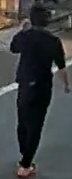

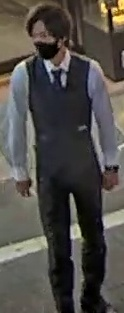

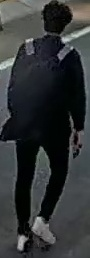

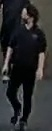

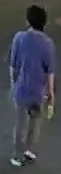

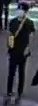

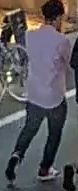

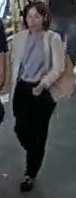

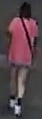

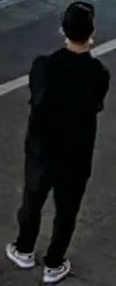

In [2]:
import glob
from IPython.display import Image, display
import random

images = []
for imageName in glob.glob('/home/pducanh/Desktop/cam2/*.jpg'):
    images.append(imageName)

for _ in range(10):
    display(
        Image(
            filename = images[random.randint(0, len(images) - 1)]
        )
)


# Extract Background

The function `extract_background` take in input the following values:

- **path_tubes**: the path of file that contains the objects' tubes;
- **source**: the path of the video, from which we want to extract the patches;
- **outputdir**: the output folder.

It returns the path of the `background.jpg`.

In [4]:
from pcgvs.extraction import extract_background

extract_background(
    path_tubes="/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/data_input_txt_object/trungquoc.txt", 
    source="/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/Video_input/video4.mp4", 
    outputdir="/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/synopsis/"
)


extracting background | frame 2
extracting background | frame 3
extracting background | frame 4
extracting background | frame 5
extracting background | frame 6
extracting background | frame 7
extracting background | frame 8
extracting background | frame 9
extracting background | frame 10
extracting background | frame 11
extracting background | frame 12
extracting background | frame 13


'/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/synopsis/background.png'

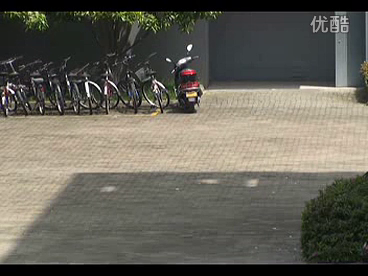

In [5]:
display(Image(filename = '/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/synopsis/background.png'))


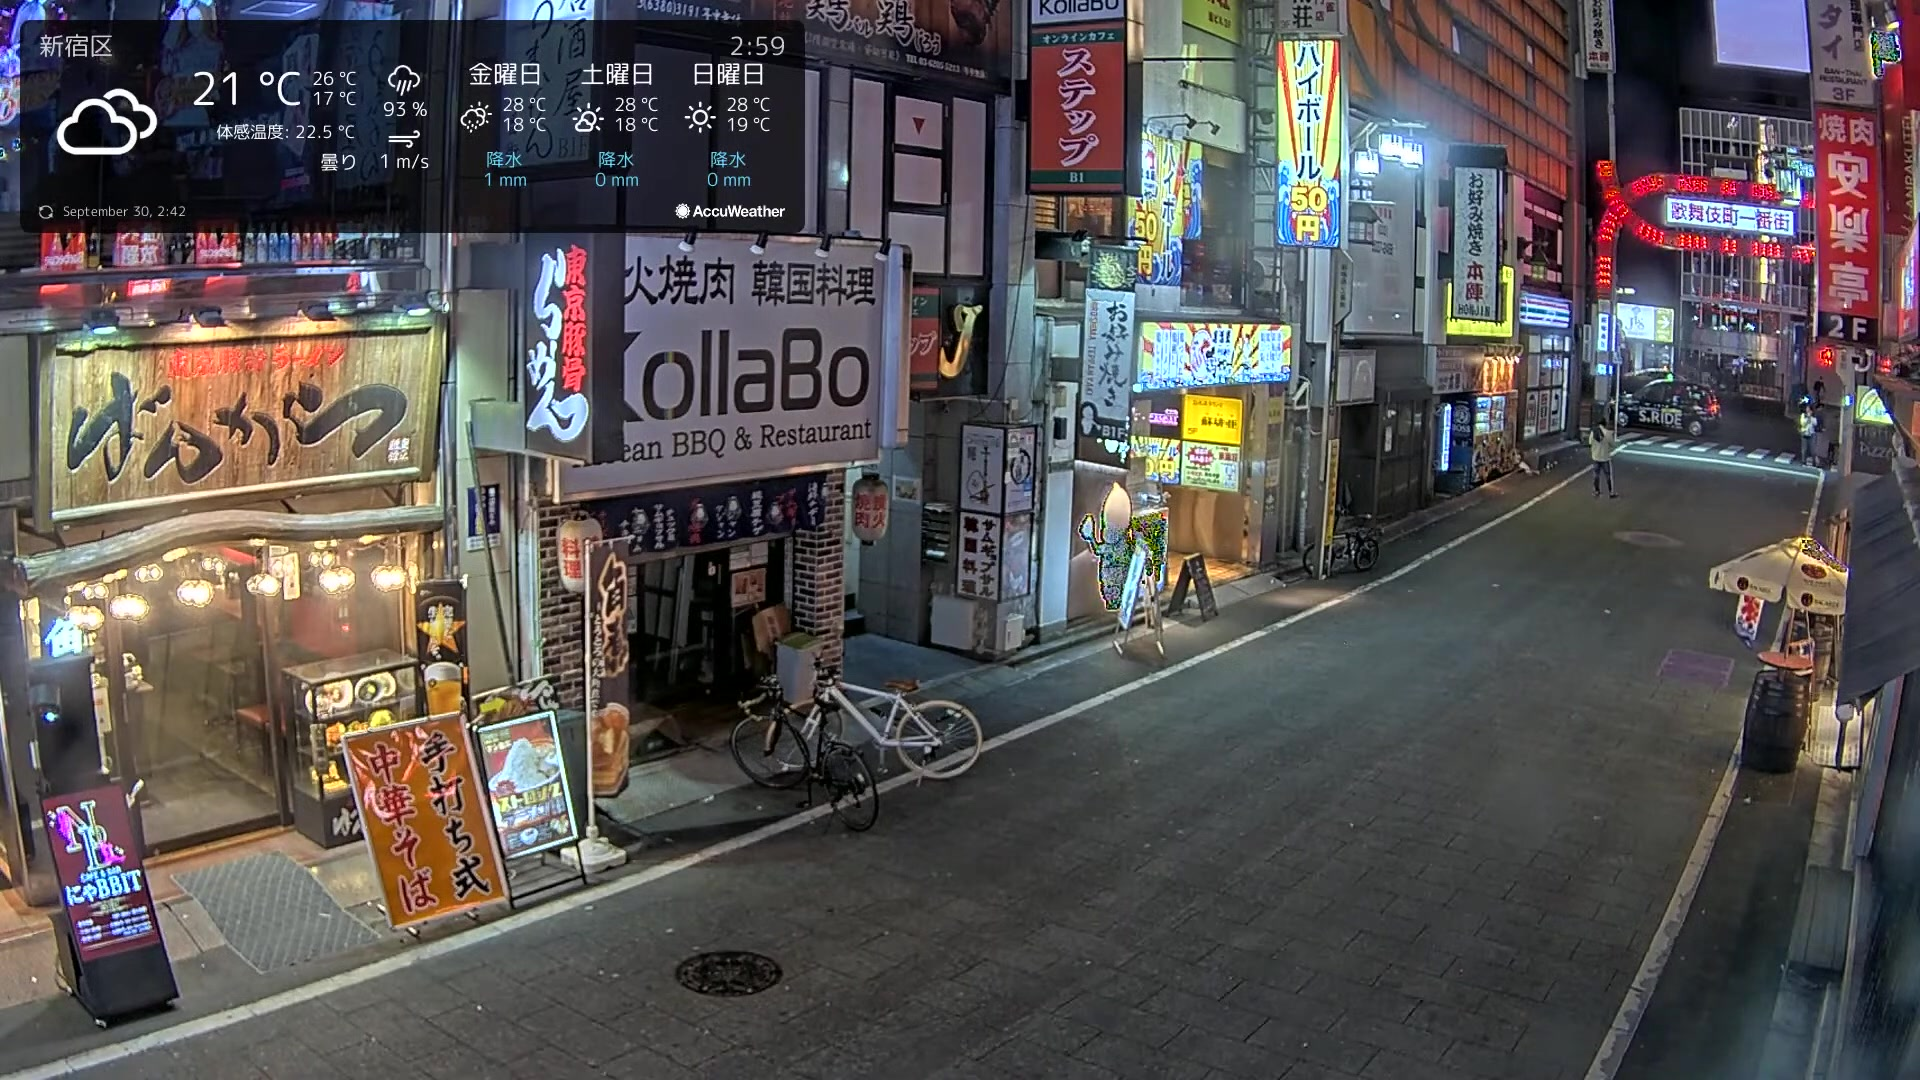

In [5]:
display(Image(filename = '/home/pducanh/Desktop/pcgvs/data/background.jpg'))